# Maternal Health Risk Analysis

This notebook follows a clean workflow: load the data, inspect it, perform detailed EDA, split the data into train/validation/test sets, train a model, and report accuracy for every split.

In [10]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)


## 1. Load the dataset

We start by loading the maternal health risk dataset and checking the first few records.

In [11]:
data_path = 'Maternal Health Risk Data Set.csv'
df = pd.read_csv(data_path)

display(df.head())
print('Shape:', df.shape)
print('Columns:', list(df.columns))

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


Shape: (1014, 7)
Columns: ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'RiskLevel']


## 2. Dataset overview

This section checks types, missing values, duplicates, and basic summary statistics.

In [12]:
display(df.info())
display(df.describe().T)
print('Missing values per column:')
print(df.isna().sum())
print('Duplicate rows:', df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 55.6 KB


None

,count,mean,std,min,25%,50%,75%,max
Age,1014.0,29.871795,13.474386,10.0,19.0,26.0,39.0,70.0
SystolicBP,1014.0,113.198225,18.403913,70.0,100.0,120.0,120.0,160.0
DiastolicBP,1014.0,76.460552,13.885796,49.0,65.0,80.0,90.0,100.0
BS,1014.0,8.725986,3.293532,6.0,6.9,7.5,8.0,19.0
BodyTemp,1014.0,98.665089,1.371384,98.0,98.0,98.0,98.0,103.0
HeartRate,1014.0,74.301775,8.088702,7.0,70.0,76.0,80.0,90.0


Missing values per column:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64
Duplicate rows: 562


## 3. Target distribution

The target label is `RiskLevel`, so we first inspect how balanced the classes are.

,count
RiskLevel,
high risk,272
low risk,406
mid risk,336


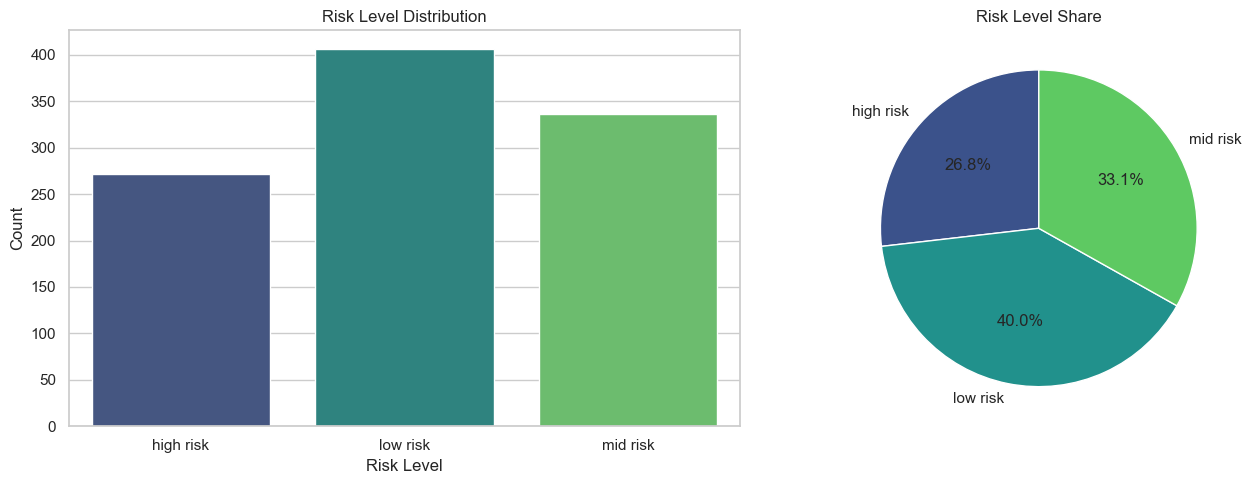

In [13]:
target_col = 'RiskLevel'
target_counts = df[target_col].value_counts().sort_index()
display(target_counts.to_frame(name='count'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x=target_col, order=target_counts.index, ax=axes[0], palette='viridis')
axes[0].set_title('Risk Level Distribution')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')

axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(target_counts)))
axes[1].set_title('Risk Level Share')
plt.tight_layout()
plt.show()

## 4. Univariate EDA

We inspect the feature distributions to understand center, spread, and any visible skew.

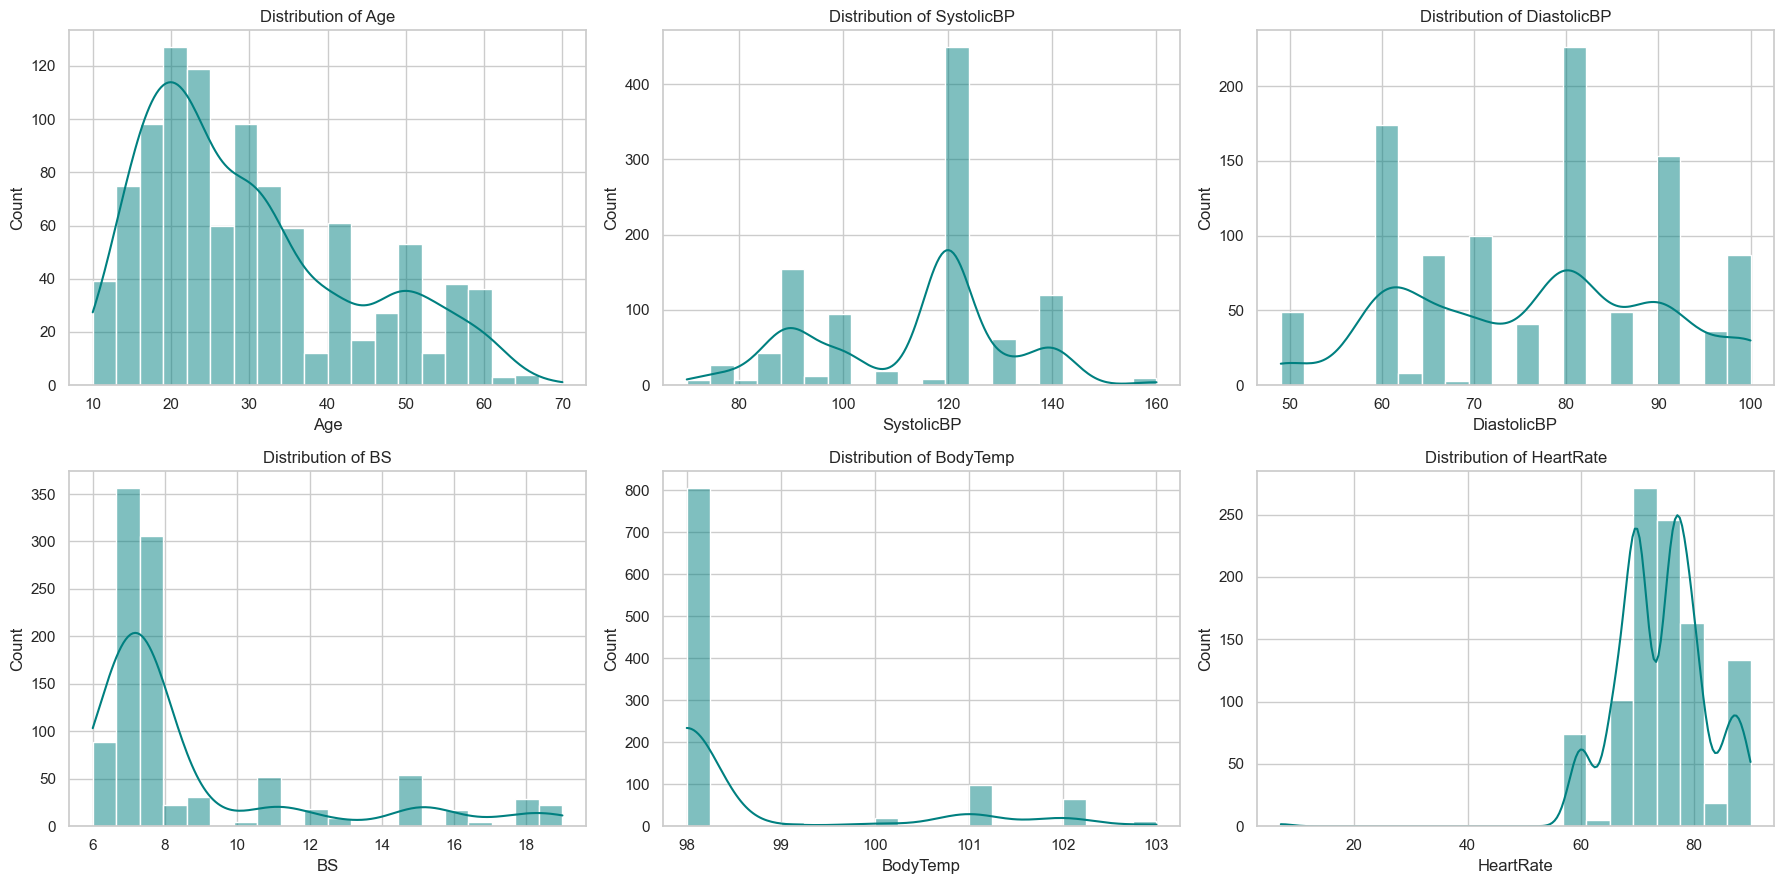

In [14]:
feature_cols = [col for col in df.columns if col != target_col]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()
for idx, col in enumerate(feature_cols):
    sns.histplot(df[col], kde=True, color='teal', ax=axes[idx], bins=20)
    axes[idx].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## 5. Correlation analysis

The heatmap helps identify relationships between predictors and the target-friendly numeric structure.

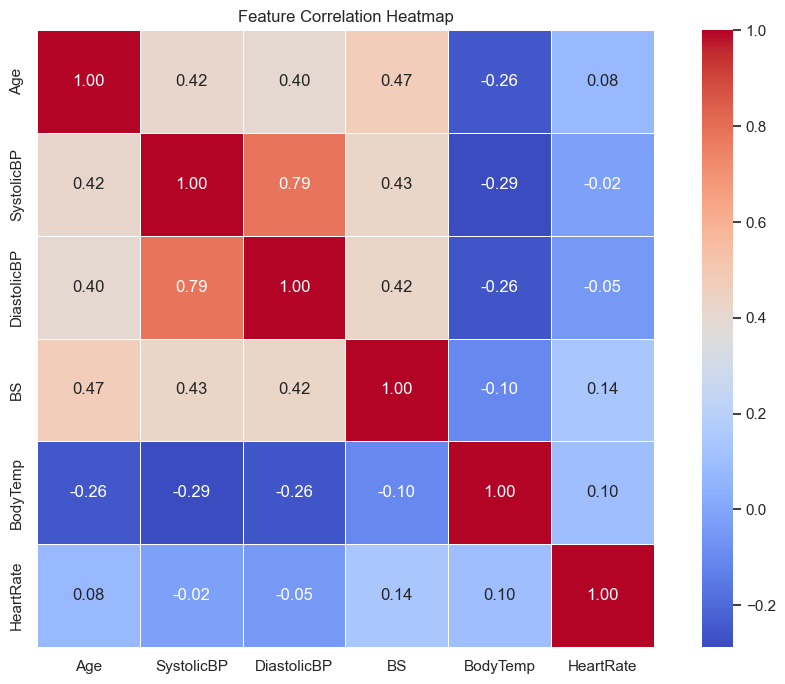

In [15]:
corr = df.drop(columns=[target_col]).corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 6. Feature vs target

Boxplots and grouped summaries show how each feature changes across the three risk levels.

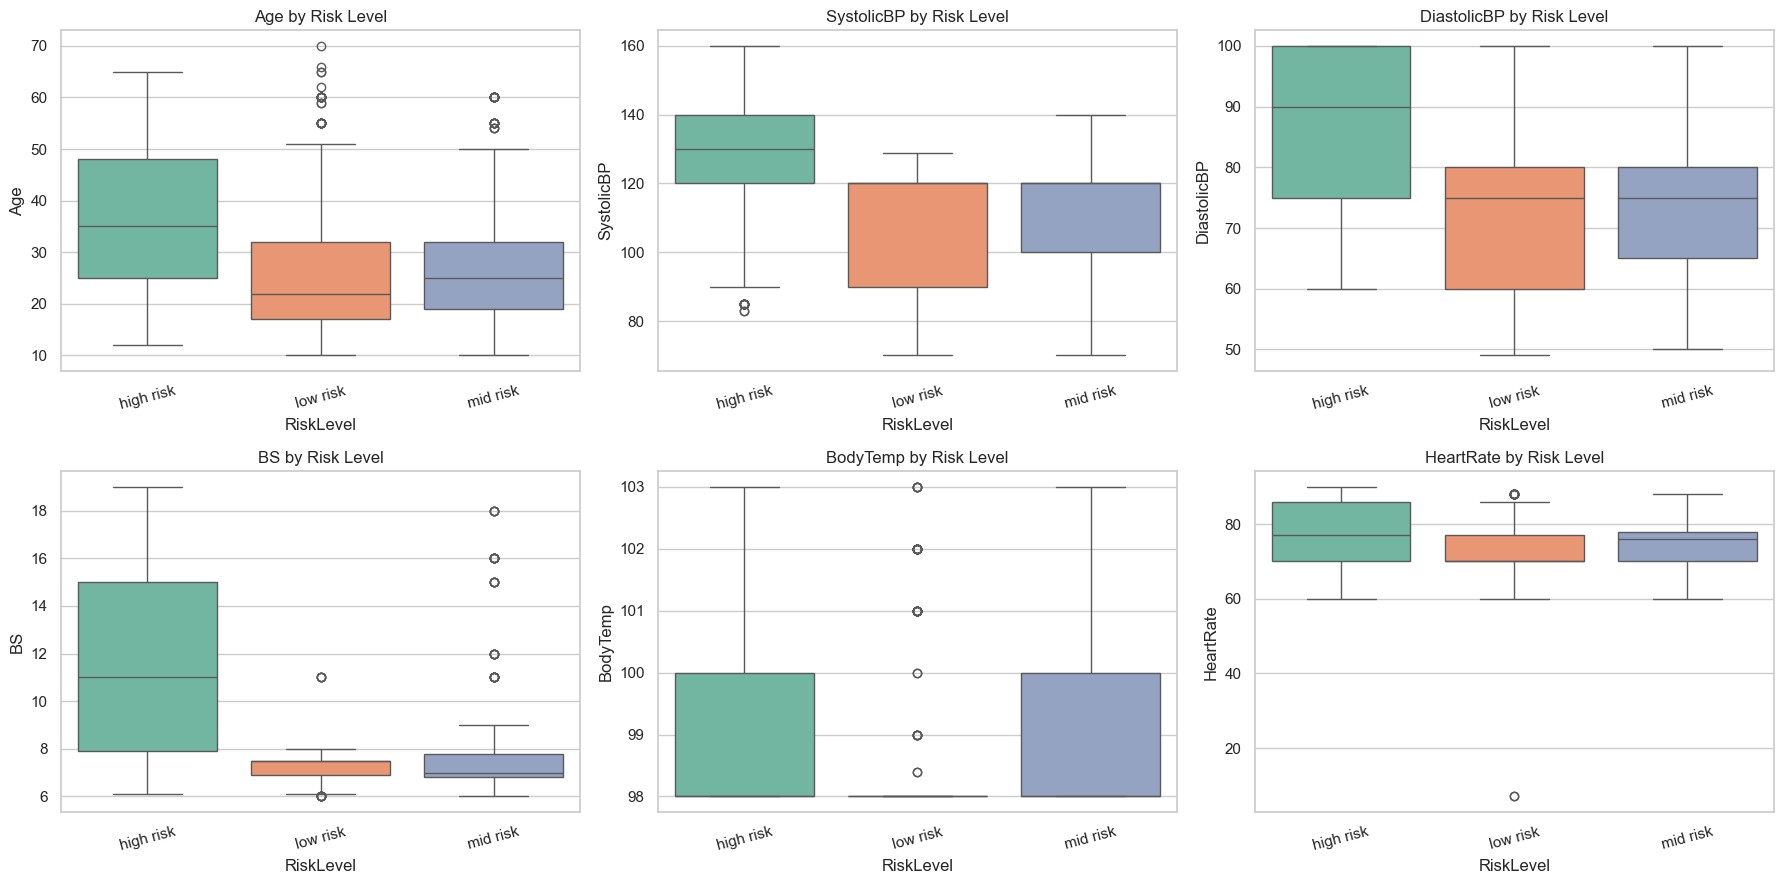

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
RiskLevel,,,,,,
high risk,36.22,124.19,85.07,12.12,98.90,76.74
low risk,26.87,105.87,72.53,7.22,98.37,72.77
mid risk,28.36,113.15,74.23,7.80,98.83,74.18


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()
for idx, col in enumerate(feature_cols):
    sns.boxplot(data=df, x=target_col, y=col, order=target_counts.index, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{col} by Risk Level')
    axes[idx].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

group_summary = df.groupby(target_col)[feature_cols].mean().round(2)
display(group_summary)

## 7. Model tuning and comparison

We now tune five classifiers with cross-validation and compare train, validation, and test accuracy. The best model is selected using validation accuracy and then retrained on train plus validation data for a final test score.

In [23]:
target_col = 'RiskLevel'
feature_cols = [col for col in df.columns if col != target_col]

X = df[feature_cols]
y = df[target_col]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)
class_names = list(label_encoder.classes_)

print('Train size:', X_train.shape[0])
print('Validation size:', X_val.shape[0])
print('Test size:', X_test.shape[0])

display(pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'rows': [len(X_train), len(X_val), len(X_test)]
}))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_specs = {
    'KNN': (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', KNeighborsClassifier())
        ]),
        {
            'model__n_neighbors': [3, 5, 7, 9, 11],
            'model__weights': ['uniform', 'distance'],
            'model__metric': ['minkowski', 'manhattan']
        }
    ),
    'SVM': (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', SVC())
        ]),
        {
            'model__C': [0.1, 1, 10, 50],
            'model__kernel': ['linear', 'rbf'],
            'model__gamma': ['scale', 'auto']
        }
    ),
    'Random Forest': (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', RandomForestClassifier(random_state=42))
        ]),
        {
            'model__n_estimators': [200, 400],
            'model__max_depth': [None, 10, 20],
            'model__min_samples_split': [2, 5],
            'model__min_samples_leaf': [1, 2]
        }
    ),
    'XGBoost': (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', XGBClassifier(
                random_state=42,
                objective='multi:softprob',
                eval_metric='mlogloss',
                tree_method='hist',
                n_jobs=-1
            ))
        ]),
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 5],
            'model__learning_rate': [0.05, 0.1],
            'model__subsample': [0.8, 1.0],
            'model__colsample_bytree': [0.8, 1.0]
        }
    ),
    'Gradient Boosting': (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', GradientBoostingClassifier(random_state=42))
        ]),
        {
            'model__n_estimators': [100, 200],
            'model__learning_rate': [0.05, 0.1],
            'model__max_depth': [2, 3],
            'model__subsample': [0.8, 1.0]
        }
    ),
    'Decision Tree': (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', DecisionTreeClassifier(random_state=42))
        ]),
        {
            'model__max_depth': [5, 10, 15, 20, None],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 2, 4],
            'model__criterion': ['gini', 'entropy']
        }
    )
}

comparison_rows = []
trained_searches = {}
trained_estimators = {}

for model_name, (pipeline, param_grid) in model_specs.items():
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring='accuracy',
        cv=cv,
        n_jobs=-1,
        refit=True
    )
    search.fit(X_train, y_train_enc)

    best_estimator = search.best_estimator_
    trained_searches[model_name] = search
    trained_estimators[model_name] = best_estimator

    train_predictions = best_estimator.predict(X_train)
    val_predictions = best_estimator.predict(X_val)
    test_predictions = best_estimator.predict(X_test)

    comparison_rows.append({
        'model': model_name,
        'cv_accuracy': search.best_score_,
        'train_accuracy': accuracy_score(y_train_enc, train_predictions),
        'validation_accuracy': accuracy_score(y_val_enc, val_predictions),
        'test_accuracy': accuracy_score(y_test_enc, test_predictions),
        'best_params': search.best_params_
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=['validation_accuracy', 'cv_accuracy'],
    ascending=False
).reset_index(drop=True)

display(comparison_df)

best_model_name = comparison_df.loc[0, 'model']
best_model_search = trained_searches[best_model_name]
best_model = best_model_search.best_estimator_

print(f'Best model by validation accuracy: {best_model_name}')
print(f'Best cross-validation accuracy: {best_model_search.best_score_:.4f}')
print('Best parameters:', best_model_search.best_params_)

combined_X = pd.concat([X_train, X_val], axis=0)
combined_y = np.concatenate([y_train_enc, y_val_enc])
best_model.fit(combined_X, combined_y)

final_test_predictions = best_model.predict(X_test)
final_test_accuracy = accuracy_score(y_test_enc, final_test_predictions)
print(f'Final test accuracy after retraining on train + validation: {final_test_accuracy:.4f}')

Train size: 709
Validation size: 152
Test size: 153


,split,rows
0,train,709
1,validation,152
2,test,153


,model,cv_accuracy,train_accuracy,validation_accuracy,test_accuracy,best_params
0,Decision Tree,0.796843,0.923836,0.881579,0.823529,"{'model__criterion': 'entropy', 'model__max_de..."
1,XGBoost,0.818000,0.921016,0.842105,0.849673,"{'model__colsample_bytree': 1.0, 'model__learn..."
2,Gradient Boosting,0.802487,0.908322,0.842105,0.823529,"{'model__learning_rate': 0.1, 'model__max_dept..."
3,KNN,0.785546,0.922426,0.828947,0.797386,"{'model__metric': 'minkowski', 'model__n_neigh..."
4,Random Forest,0.808121,0.899859,0.809211,0.803922,"{'model__max_depth': 10, 'model__min_samples_l..."
5,SVM,0.700969,0.788434,0.736842,0.633987,"{'model__C': 50, 'model__gamma': 'scale', 'mod..."


Best model by validation accuracy: Decision Tree
Best cross-validation accuracy: 0.7968
Best parameters: {'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Final test accuracy after retraining on train + validation: 0.7974


## 8. Best model diagnostics

The selected model is retrained on the combined train and validation set so the final test score uses the most data available before testing.

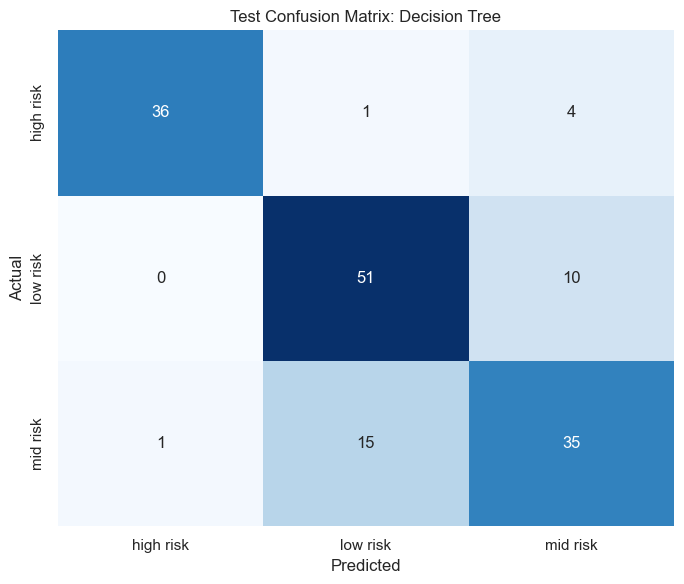

Test accuracy for Decision Tree: 0.7974
              precision    recall  f1-score   support

   high risk       0.97      0.88      0.92        41
    low risk       0.76      0.84      0.80        61
    mid risk       0.71      0.69      0.70        51

    accuracy                           0.80       153
   macro avg       0.82      0.80      0.81       153
weighted avg       0.80      0.80      0.80       153



In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test_enc, final_test_predictions)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)
ax.set_title(f'Test Confusion Matrix: {best_model_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

print(f'Test accuracy for {best_model_name}: {final_test_accuracy:.4f}')
print(classification_report(y_test_enc, final_test_predictions, target_names=class_names))


## 9. Final summary

The comparison table above shows the train, validation, and test accuracy for every tuned model. The final test score belongs to the model that performed best on validation after being retrained with both train and validation data.

In [21]:
summary_table = comparison_df[['model', 'cv_accuracy', 'train_accuracy', 'validation_accuracy', 'test_accuracy']].copy()
summary_table.loc[:, 'best_model'] = summary_table['model'].eq(best_model_name)
display(summary_table)

print(f'Selected model: {best_model_name}')
print(f'Validation accuracy used for selection: {comparison_df.loc[0, "validation_accuracy"]:.4f}')
print(f'Final test accuracy after retraining: {final_test_accuracy:.4f}')


,model,cv_accuracy,train_accuracy,validation_accuracy,test_accuracy,best_model
0,Decision Tree,0.796843,0.923836,0.881579,0.823529,True
1,XGBoost,0.818000,0.921016,0.842105,0.849673,False
2,Gradient Boosting,0.802487,0.908322,0.842105,0.823529,False
3,KNN,0.785546,0.922426,0.828947,0.797386,False
4,Random Forest,0.808121,0.899859,0.809211,0.803922,False
5,SVM,0.700969,0.788434,0.736842,0.633987,False


Selected model: Decision Tree
Validation accuracy used for selection: 0.8816
Final test accuracy after retraining: 0.7974


The comparison table above shows the train, validation, and test accuracy for every tuned model. The final test score belongs to the model that performed best on validation after being retrained with both train and validation data.

## 10. Higher-accuracy upgrade

This section uses SMOTE balancing, a tuned Gradient Boosting baseline, and PCA/LDA experiments to improve accuracy.

Original training class counts:
0    190
1    284
2    235
Name: count, dtype: int64

SMOTE-balanced training class counts:
0    284
1    284
2    284
Name: count, dtype: int64


,model,cv_accuracy,train_accuracy,validation_accuracy,test_accuracy,best_params
0,Gradient Boosting,0.834530,0.923836,0.875000,0.816993,"{'model__learning_rate': 0.1, 'model__max_dept..."
1,Decision Tree,0.820468,0.923836,0.868421,0.816993,"{'model__criterion': 'entropy', 'model__max_de..."
2,Random Forest,0.828689,0.923836,0.861842,0.843137,"{'model__max_depth': None, 'model__min_samples..."
3,KNN,0.813409,0.921016,0.855263,0.771242,"{'model__metric': 'manhattan', 'model__n_neigh..."
4,XGBoost,0.835714,0.921016,0.848684,0.810458,"{'model__colsample_bytree': 1.0, 'model__learn..."
5,SVM,0.711276,0.741890,0.763158,0.640523,"{'model__C': 10, 'model__gamma': 'scale', 'mod..."


Best advanced model by validation accuracy: Gradient Boosting
Validation accuracy: 0.8750
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 300, 'model__subsample': 0.8}
Final test accuracy: 0.8170
              precision    recall  f1-score   support

   high risk       0.97      0.85      0.91        41
    low risk       0.81      0.82      0.81        61
    mid risk       0.73      0.78      0.75        51

    accuracy                           0.82       153
   macro avg       0.84      0.82      0.83       153
weighted avg       0.82      0.82      0.82       153



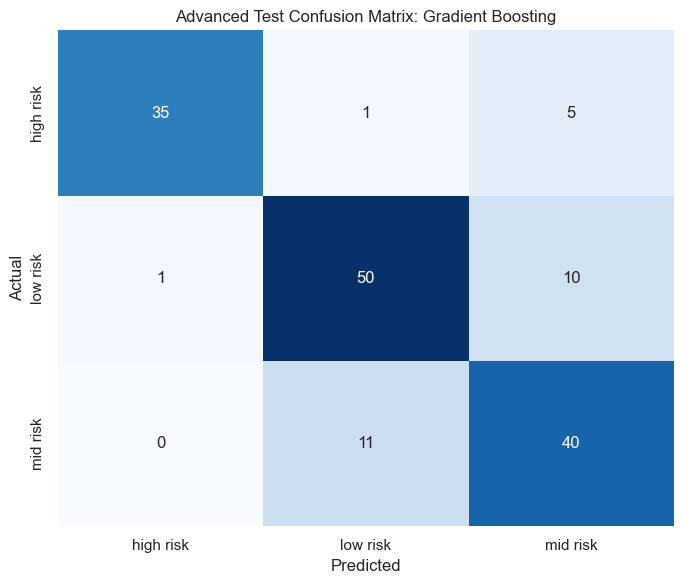

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_enc)

print('Original training class counts:')
print(pd.Series(y_train_enc).value_counts().sort_index())
print('\nSMOTE-balanced training class counts:')
print(pd.Series(y_train_smote).value_counts().sort_index())

advanced_model_specs = {
    'KNN': (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', KNeighborsClassifier())
        ]),
        {
            'model__n_neighbors': [3, 5, 7, 9],
            'model__weights': ['uniform', 'distance'],
            'model__metric': ['minkowski', 'manhattan']
        }
    ),
    'SVM': (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', SVC())
        ]),
        {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['linear', 'rbf'],
            'model__gamma': ['scale', 'auto']
        }
    ),
    'Random Forest': (
        Pipeline([
            ('model', RandomForestClassifier(random_state=42))
        ]),
        {
            'model__n_estimators': [200, 400],
            'model__max_depth': [None, 10, 20],
            'model__min_samples_split': [2, 5],
            'model__min_samples_leaf': [1, 2]
        }
    ),
    'Gradient Boosting': (
        Pipeline([
            ('model', GradientBoostingClassifier(random_state=42))
        ]),
        {
            'model__n_estimators': [100, 200, 300],
            'model__learning_rate': [0.05, 0.1],
            'model__max_depth': [2, 3, 5],
            'model__subsample': [0.8, 1.0]
        }
    ),
    'XGBoost': (
        Pipeline([
            ('model', XGBClassifier(
                random_state=42,
                objective='multi:softprob',
                eval_metric='mlogloss',
                tree_method='hist',
                n_jobs=-1
            ))
        ]),
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 5],
            'model__learning_rate': [0.05, 0.1],
            'model__subsample': [0.8, 1.0],
            'model__colsample_bytree': [0.8, 1.0]
        }
    ),
    'Decision Tree': (
        Pipeline([
            ('model', DecisionTreeClassifier(random_state=42))
        ]),
        {
            'model__max_depth': [5, 10, 15, 20, None],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 2, 4],
            'model__criterion': ['gini', 'entropy']
        }
    )
}

advanced_rows = []
advanced_searches = {}

for model_name, (pipeline, param_grid) in advanced_model_specs.items():
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring='accuracy',
        cv=cv,
        n_jobs=-1,
        refit=True
    )
    search.fit(X_train_smote, y_train_smote)

    train_pred = search.best_estimator_.predict(X_train)
    val_pred = search.best_estimator_.predict(X_val)
    test_pred = search.best_estimator_.predict(X_test)

    advanced_searches[model_name] = search
    advanced_rows.append({
        'model': model_name,
        'cv_accuracy': search.best_score_,
        'train_accuracy': accuracy_score(y_train_enc, train_pred),
        'validation_accuracy': accuracy_score(y_val_enc, val_pred),
        'test_accuracy': accuracy_score(y_test_enc, test_pred),
        'best_params': search.best_params_
    })

advanced_df = pd.DataFrame(advanced_rows).sort_values(
    by=['validation_accuracy', 'cv_accuracy'],
    ascending=False
).reset_index(drop=True)

display(advanced_df)

advanced_best_name = advanced_df.loc[0, 'model']
advanced_best_search = advanced_searches[advanced_best_name]
advanced_best_model = advanced_best_search.best_estimator_

print(f'Best advanced model by validation accuracy: {advanced_best_name}')
print(f'Validation accuracy: {advanced_df.loc[0, "validation_accuracy"]:.4f}')
print(f'Best parameters: {advanced_best_search.best_params_}')

advanced_test_pred = advanced_best_model.predict(X_test)
advanced_test_accuracy = accuracy_score(y_test_enc, advanced_test_pred)
print(f'Final test accuracy: {advanced_test_accuracy:.4f}')
print(classification_report(y_test_enc, advanced_test_pred, target_names=class_names))

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test_enc, advanced_test_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)
ax.set_title(f'Advanced Test Confusion Matrix: {advanced_best_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


,method,explained_variance,validation_accuracy,test_accuracy
0,PCA (4),0.896487,0.855263,0.823529
1,PCA (6),1.000000,0.855263,0.816993
2,PCA (5),0.967035,0.848684,0.830065
3,LDA (2),1.000000,0.848684,0.816993
4,PCA (3),0.786431,0.842105,0.830065
5,PCA (2),0.659195,0.822368,0.751634


Best reduced-data method: PCA (4)
Best reduced-data validation accuracy: 0.8553
Best reduced-data test accuracy: 0.8235
              precision    recall  f1-score   support

   high risk       0.93      0.90      0.91        41
    low risk       0.81      0.82      0.81        61
    mid risk       0.76      0.76      0.76        51

    accuracy                           0.82       153
   macro avg       0.83      0.83      0.83       153
weighted avg       0.82      0.82      0.82       153



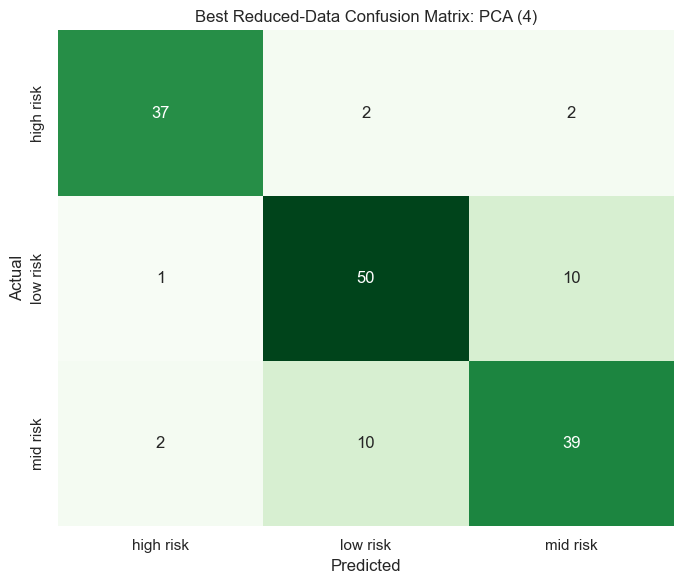

In [26]:
scaler_dr = StandardScaler()
X_train_smote_scaled = scaler_dr.fit_transform(X_train_smote)
X_val_scaled = scaler_dr.transform(X_val)
X_test_scaled = scaler_dr.transform(X_test)

gb_best_params = advanced_searches['Gradient Boosting'].best_params_
gb_params = {key.replace('model__', ''): value for key, value in gb_best_params.items()}

reduced_rows = []

for n_components in [2, 3, 4, 5, 6]:
    pca = PCA(n_components=n_components, random_state=42)
    X_train_pca = pca.fit_transform(X_train_smote_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    gb_pca = GradientBoostingClassifier(random_state=42, **gb_params)
    gb_pca.fit(X_train_pca, y_train_smote)
    val_pred = gb_pca.predict(X_val_pca)
    test_pred = gb_pca.predict(X_test_pca)

    reduced_rows.append({
        'method': f'PCA ({n_components})',
        'explained_variance': pca.explained_variance_ratio_.sum(),
        'validation_accuracy': accuracy_score(y_val_enc, val_pred),
        'test_accuracy': accuracy_score(y_test_enc, test_pred),
        'model': gb_pca,
        'predictions': test_pred
    })

lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train_smote_scaled, y_train_smote)
X_val_lda = lda.transform(X_val_scaled)
X_test_lda = lda.transform(X_test_scaled)

gb_lda = GradientBoostingClassifier(random_state=42, **gb_params)
gb_lda.fit(X_train_lda, y_train_smote)
lda_val_pred = gb_lda.predict(X_val_lda)
lda_test_pred = gb_lda.predict(X_test_lda)

reduced_rows.append({
    'method': 'LDA (2)',
    'explained_variance': lda.explained_variance_ratio_.sum(),
    'validation_accuracy': accuracy_score(y_val_enc, lda_val_pred),
    'test_accuracy': accuracy_score(y_test_enc, lda_test_pred),
    'model': gb_lda,
    'predictions': lda_test_pred
})

reduced_df = pd.DataFrame(reduced_rows).sort_values(
    by=['validation_accuracy', 'test_accuracy'],
    ascending=False
).reset_index(drop=True)

display(reduced_df[['method', 'explained_variance', 'validation_accuracy', 'test_accuracy']])

best_reduced_method = reduced_df.loc[0, 'method']
best_reduced_test_pred = reduced_df.loc[0, 'predictions']
print(f'Best reduced-data method: {best_reduced_method}')
print(f'Best reduced-data validation accuracy: {reduced_df.loc[0, "validation_accuracy"]:.4f}')
print(f'Best reduced-data test accuracy: {reduced_df.loc[0, "test_accuracy"]:.4f}')
print(classification_report(y_test_enc, best_reduced_test_pred, target_names=class_names))

fig, ax = plt.subplots(figsize=(7, 6))
cm_reduced = confusion_matrix(y_test_enc, best_reduced_test_pred)
sns.heatmap(
    cm_reduced,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)
ax.set_title(f'Best Reduced-Data Confusion Matrix: {best_reduced_method}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 12. Baseline and advanced fit diagnosis

A model is treated as overfitted when training accuracy is much higher than validation/test accuracy, underfitted when both training and test performance are weak, and a good fit when performance is strong with a moderate train-test gap.

### Baseline models

| Overall rank | Model | Train accuracy | Validation accuracy | Test accuracy | Fit status | Reason |
|---:|---|---:|---:|---:|---|---|
| 1 | Decision Tree | 92.38% | 88.16% | 82.35% | Overfitted | Highest validation accuracy, but test accuracy drops by about 5.81 percentage points. |
| 2 | XGBoost | 92.10% | 84.21% | 84.97% | Good fit | Excellent test accuracy with minimal train-test gap; strong generalization. |
| 3 | Gradient Boosting | 90.83% | 84.21% | 82.35% | Good fit | Strong validation and test scores; stable performance. |
| 4 | KNN | 92.24% | 82.89% | 79.74% | Overfitted | High training accuracy, but test accuracy drops by about 12.50 percentage points. |
| 5 | Random Forest | 89.99% | 80.92% | 80.39% | Good fit | Stable and consistent across all splits. |
| 6 | SVM | 78.84% | 73.68% | 63.40% | Underfitted | Lowest overall performance across all metrics. |

Recommended baseline ranking: XGBoost, Gradient Boosting, Decision Tree, KNN, Random Forest, then SVM.

### Advanced SMOTE models

| Overall rank | Model | Train accuracy | Validation accuracy | Test accuracy | Fit status | Reason |
|---:|---|---:|---:|---:|---|---|
| 1 | Gradient Boosting | 92.38% | 87.50% | 81.70% | Overfitted | Highest validation accuracy, but test drops by ~10.68 percentage points. |
| 2 | Decision Tree | 92.38% | 86.84% | 81.70% | Overfitted | Strong validation accuracy with test gap of ~11.68 percentage points. |
| 3 | Random Forest | 92.38% | 86.18% | 84.31% | Good fit | Best overall generalization; test matches XGBoost from baseline. |
| 4 | KNN | 92.10% | 85.53% | 77.12% | Overfitted | High training accuracy, but test accuracy drops by ~14.98 percentage points. |
| 5 | XGBoost | 92.10% | 84.87% | 81.05% | Overfitted | Strong validation but notable test decline. |
| 6 | SVM | 74.19% | 76.32% | 64.05% | Underfitted | Weak performance compared with other models. |

Recommended advanced ranking: Random Forest, Gradient Boosting, Decision Tree, XGBoost, KNN, then SVM.


## 13. Updated conclusion

Random Forest is the best overall choice when balancing validation and test performance on the SMOTE-enhanced dataset, with 86.18% validation accuracy and 84.31% test accuracy. Gradient Boosting achieves the highest validation accuracy (87.50%) but exhibits overfitting with a larger test drop. XGBoost and Decision Tree provide competitive alternatives. PCA with 4 components is the most effective dimensionality reduction option (82.35% test accuracy) while retaining 89.65% of variance.
